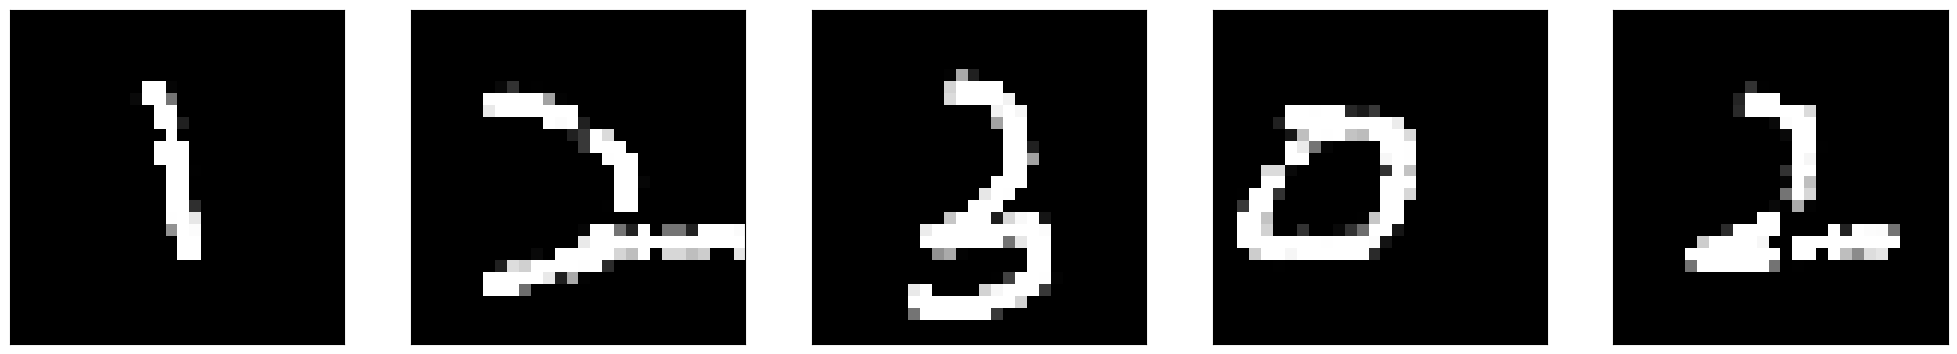

1/1 [==============================] - 3s 3s/step


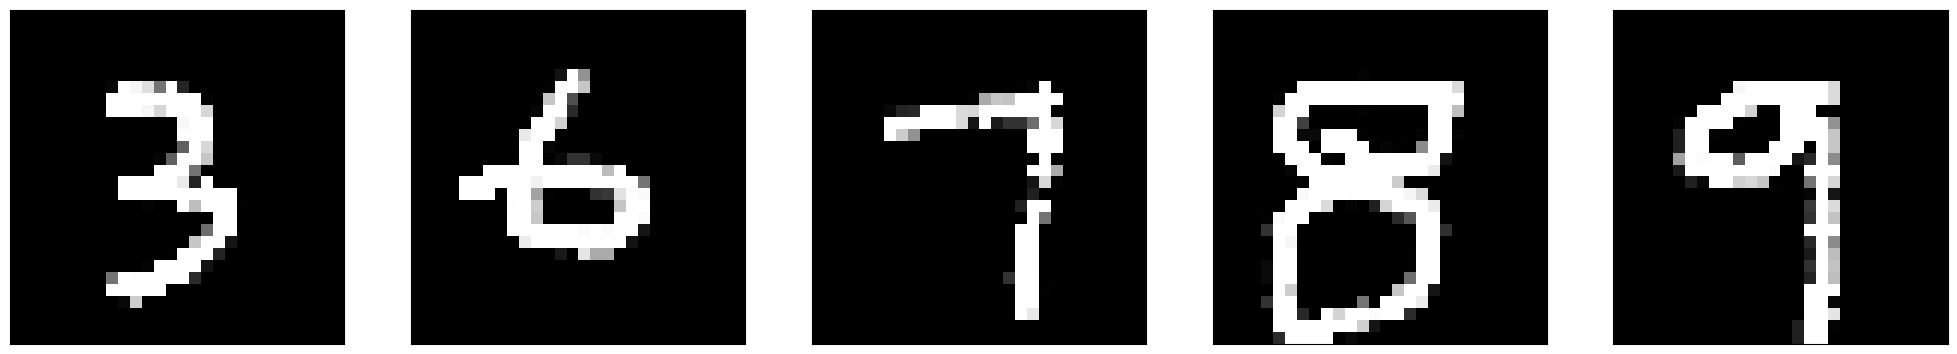

1/1 [==============================] - 0s 11ms/step


In [1]:
import numpy as np
import tensorflow as tf
import cv2 as cv 
import matplotlib.pyplot as plt
import winsound

# [1] 학습된 CNN 모델 불러오기
model = tf.keras.models.load_model('cnn_v2.h5')

# [2] 쓰기 캔버스 초기화 함수
def reset():
    global img
    # 흰 배경 (200x520), 3채널(BGR)
    img = np.ones((200, 520, 3), dtype=np.uint8) * 255

    # 숫자 5개를 쓸 수 있는 빨간 사각형 영역 그리기
    for i in range(5):
        cv.rectangle(img, (10 + i * 100, 50), (10 + (i + 1) * 100, 150), (0, 0, 255))

    # 단축키 안내 텍스트
    cv.putText(
        img,
        'e:erase s:show r:recognition q:quit',
        (10, 40),
        cv.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        1
    )

# [3] 사각형 칸 안의 숫자 ROI 잘라내서 전처리
def grab_numerals():
    numerals = []
    for i in range(5):
        # 파란 채널만 사용해서 ROI 추출
        roi = img[51:149, 11 + i * 100 : 9 + (i + 1) * 100, 0]

        # MNIST 형태 맞게 색 반전 + 28x28 리사이즈
        roi = 255 - cv.resize(roi, (28, 28), interpolation=cv.INTER_CUBIC)

        numerals.append(roi)

    numerals = np.array(numerals)
    return numerals

# [4] 잘라낸 숫자 시각화 (Matplotlib)
def show():
    numerals = grab_numerals()
    plt.figure(figsize=(25, 5))
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(numerals[i], cmap='gray')
        plt.xticks([]); plt.yticks([])
    plt.show()

# [5] 신경망 모델로 숫자 인식 후 결과 표시
def recognition():
    numerals = grab_numerals()
    numerals = numerals.reshape(5, 28, 28, 1)  # Conv2D 입력 모양
    numerals = numerals.astype(np.float32) / 255.0  # 정규화

    res = model.predict(numerals)  # CNN으로 예측
    class_id = np.argmax(res, axis=1)  # 예측 결과 (가장 확률 높은 클래스)

    # 인식 결과 숫자를 사각형 아래에 표시
    for i in range(5):
        cv.putText(
            img, str(class_id[i]),
            (50 + i * 100, 180),
            cv.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1
        )

    winsound.Beep(1000, 500)  # 인식 후 비프음

# [6] 쓰기 도구 설정 (붓 크기, 색상)
BrushSiz = 4
LColor = (0, 0, 0)

# [7] 마우스 콜백: 마우스로 숫자 쓰기
def writing(event, x, y, flags, param):
    if event == cv.EVENT_LBUTTONDOWN:
        cv.circle(img, (x, y), BrushSiz, LColor, -1)
    elif event == cv.EVENT_MOUSEMOVE and flags == cv.EVENT_FLAG_LBUTTON:
        cv.circle(img, (x, y), BrushSiz, LColor, -1)

# [8] 윈도우 초기화 & 마우스 콜백 등록
reset()
cv.namedWindow('Writing')
cv.setMouseCallback('Writing', writing)

# [9] GUI 루프: 키 입력 처리 (지우기/보기/인식/종료)
while True:
    cv.imshow('Writing', img)
    key = cv.waitKey(1)

    if key == ord('e'):
        reset()           # e: 지우기
    elif key == ord('s'):
        show()            # s: 숫자 보기
    elif key == ord('r'):
        recognition()     # r: 숫자 인식
    elif key == ord('q'):
        break             # q: 종료

cv.destroyAllWindows()
